In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import colorsys
import itertools as it
import pandas as pd
from datetime import datetime as dt
from datetime import timedelta
from pathlib import Path
from hypo_sleep import NumpyDecoder
import spikeinterface.full as si
import spikeinterface.preprocessing as spp
from scipy import signal, stats
import xarray as xr
import statsmodels.api as sm
import statsmodels.formula.api as smf
from functools import partial
from ghostipy.dsp import signal_envelope
import re
from nitime.utils import dpss_windows
import json

import pdb

In [2]:
def mt_specpb(data, Fs=1000, NW=4, chunk_size=None, chunk_avg=False):
    tapers, _ = dpss_windows(data.shape[-1], NW, 2 * NW - 1)  # Compute the tapers,
    tapers *= np.sqrt(Fs)  # ... and scale them.
    if chunk_size is None:
        chunk_size = data.shape[0]

    nchunks = int(np.ceil(data.shape[0] / chunk_size))
    spectra = []
    spectra_sem = []

    for i in range(nchunks):
        chunk = data[i * chunk_size : (i + 1) * chunk_size, :]
        # Taper and FFT
        dataT = np.array(
            [[trial * t for t in tapers] for trial in chunk]
        )  # shape: (nchunk, k, time)
        T = np.fft.rfft(tapers, axis=-1)  # shape: (k, nf)
        J = np.fft.rfft(dataT, axis=-1)  # shape: (nchunk, k, nf)

        # Subtract DC
        dc = np.array([T * trial.mean() for trial in chunk])  # shape: (nchunk, k, nf)
        J -= dc

        # Spectrum: power
        J *= J.conj()  # power
        S_chunk = J.mean(1).real
        spectra.append(np.mean(S_chunk, axis=0))  # mean across chunk
        spectra_sem.append(stats.sem(S_chunk, axis=0))
    spectra = np.stack(spectra)  # shape: (nchunks, nf)
    spectra_sem = np.stack(spectra_sem)
    f = np.fft.rfftfreq(data.shape[-1], 1 / Fs)
    if chunk_avg:
        spectra = spectra.mean(0)  # Average across trials.
        spectra_sem = spectra_sem.mean(0)
    return f, spectra, spectra_sem

In [3]:
data_path = Path("/gpfs01/born/animal/DanielG/hypo_sleep/processed_data/")
full_dict = {
    "none": {
        "dates": [
            "2024-05-21_10-28-00",
            "2024-05-23_06-00-36",
            "2024-07-22_10-47-00",
            "2024-07-23_05-47-21",
            "2024-07-23_12-06-25",
            "2024-07-25_05-55-34",
            "2024-07-25_12-18-59",
            "2025-02-18_09-19-26",
            "2025-02-20_08-58-57",
            "2025-03-20_09-01-41",
            "2025-02-24_09-00-29",
            # "2025-02-26_09-05-08",
        ],
        "configs": [
            "55a4",
            "929a",
            "3ad9",
            "20a7",
            "f9f7",
            "1f25",
            "70eb",
            "5d77",
            "790d",
            "8a55",
            "3e4b",
            # "d205",
        ],
        "animal": [
            "HYDO01",
            "HYDO01",
            "HYDO02",
            "HYDO02",
            "HYDO02",
            "HYDO02",
            "HYDO02",
            "HYDO03",
            "HYDO03",
            "HYDO03",
            "HYDO04",
        ],  # "HYDO04"],
    },
    "sleep": {
        "dates": [
            "2025-02-19_08-59-23",
            "2025-03-03_08-55-10",
            "2025-02-25_09-06-23",
            "2025-03-07_08-52-44",
        ],
        "configs": [
            "d628",
            "c687",
            "073a",
            "9080",
        ],
        "animal": ["HYDO03", "HYDO03", "HYDO04", "HYDO04"],
    },
    "food": {
        "dates": [
            "2025-02-21_09-04-29",
            "2025-02-28_09-02-06",
            "2025-03-04_08-55-25",
        ],
        "configs": [
            "a964",
            "0674",
            "bc96",
        ],
        "animal": ["HYDO03", "HYDO03", "HYDO04"],
    },
}
depth_ordered_chs = {
    "HYDO01": np.array(
        [
            "14",
            "31",
            "1",
            "16",
            "13",
            "15",
            "2",
            "30",
            "0",
            "17",
            "12",
            "9",
            "3",
            "29",
            "6",
            "18",
            "11",
            "8",
            "4",
            "28",
            "7",
            "19",
            "25",
            "5",
            "26",
            "22",
            "21",
            "24",
            "20",
            "23",
        ]
    ),
    "HYDO02": np.array(
        [
            "14",
            "31",
            "1",
            "16",
            "13",
            "15",
            "2",
            "30",
            "0",
            "17",
            "12",
            "9",
            "3",
            "29",
            "6",
            "18",
            "11",
            "8",
            "4",
            "28",
            "7",
            "19",
            "25",
            "5",
            "26",
            "22",
            "21",
            "24",
            "20",
            "23",
        ]
    ),
    "HYDO03": np.array(
        [
            "24",
            "23",
            "25",
            "22",
            "8",
            "7",
            "9",
            "6",
            "15",
            "0",
            "14",
            "1",
            "26",
            "21",
            "27",
            "20",
            "10",
            "5",
            "28",
            "19",
            "11",
            "4",
            "29",
            "18",
            "12",
            "3",
            "30",
            "17",
            "13",
            "2",
            "31",
            "16",
        ]
    ),
    "HYDO04": np.array(
        [
            "24",
            "23",
            "25",
            "22",
            "8",
            "7",
            "9",
            "6",
            "15",
            "0",
            "14",
            "1",
            "26",
            "21",
            "27",
            "20",
            "10",
            "5",
            "28",
            "19",
            "11",
            "4",
            "29",
            "18",
            "12",
            "3",
            "30",
            "17",
            "13",
            "2",
            "31",
            "16",
        ]
    ),
}
triggers = ["spi-peak", "so-peak", "nrem-null"]

In [4]:
states = ["nrem-all", "rem-all", "wake-all"]
state_data_dict = {
    cond: {date: {state: None for state in states} for date in meta_dict["dates"]}
    for cond, meta_dict in full_dict.items()
}
print("loading mua")
# for cond, meta_dict in full_dict.items():
cond = "none"
meta_dict = full_dict[cond]
for animal, date, config_id in zip(
    meta_dict["animal"], meta_dict["dates"], meta_dict["configs"]
):
    tmp_output_path = Path(
        "/gpfs01/born/animal/DanielG/hypo_sleep/processed_data/",
        animal,
        date,
        config_id,
        "mua",
    )
    for state in state_data_dict[cond][date].keys():
        load_path = Path(
            tmp_output_path,
            f"5ms_resamp_mua_{state}_39_mua_4-5thresh_4s_baa2_{config_id}",
        )
        if load_path.exists():
            files = list(load_path.glob("*.nc"))
            if len(files) < 1:
                print(f"{load_path} is empty")
            else:
                tmp_xrs = []
                for file in files:
                    tmp_xrs.append(xr.load_dataarray(file, engine="h5netcdf"))
                state_data_dict[cond][date][state] = xr.concat(tmp_xrs, dim="time")
                # state_data_dict[cond][date][state] = xr.open_mfdataset(
                #     files, engine="h5netcdf"
                # )
            # for file in files:
            #     ch = int(file.name.split(".")[0])
            #     tmp_da = xr.open_mfdataset(file, engine="h5netcdf")
            #     tmp_dict[ch] = tmp_da
        else:
            raise ValueError(f"Path {load_path} does not exist")

loading mua
/gpfs01/born/animal/DanielG/hypo_sleep/processed_data/HYDO03/2025-03-20_09-01-41/8a55/mua/5ms_resamp_mua_rem-all_39_mua_4-5thresh_4s_baa2_8a55 is empty


In [4]:
config_path = Path("/gpfs01/born/animal/DanielG/hypo_sleep/processed_data/")
session_dict = {}
animal_dict = full_dict["none"]
for animal, date, config_id in zip(
    animal_dict["animal"], animal_dict["dates"], animal_dict["configs"]
):
    with open(Path(config_path, animal, date, config_id, "state_dict.json"), "r") as f:
        state_dict = json.load(f, cls=NumpyDecoder)
    session_dict[date] = state_dict

In [5]:
epoch_state_dict = {
    state: {animal: [] for animal in set(animal_dict["animal"])} for state in states
}
for date, states in state_data_dict["none"].items():
    date_dt = dt.strptime(date, "%Y-%m-%d_%H-%M-%S")
    base_dt_64 = pd.to_datetime(date_dt, unit="ns")
    animal = [
        animal
        for animal, tmp_date in zip(
            full_dict["none"]["animal"], full_dict["none"]["dates"]
        )
        if tmp_date == date
    ][0]
    for state, data in states.items():
        if data is not None:
            data = data.sortby("time")
            state_key = state.split("-")[0].upper()
            times = session_dict[date][state_key]["times"].T
            starts = pd.to_timedelta(times[:, 0], unit="s")
            stops = pd.to_timedelta(times[:, 1], unit="s")
            xr_epochs = []
            for epoch, (start, stop) in enumerate(zip(starts, stops)):

                # delta_times = pd.to_timedelta([start, stop], unit="s")
                tmp_data = data.sel(time=slice(base_dt_64 + start, base_dt_64 + stop))

                if tmp_data.time.size > 0:
                    xr_epochs.append(tmp_data)
                else:
                    print(f"{date} {state} {epoch}: empty slice")

            epoch_state_dict[state][animal].extend(xr_epochs)

2025-02-18_09-19-26 nrem-all 0: empty slice
2025-02-18_09-19-26 nrem-all 1: empty slice
2025-02-18_09-19-26 nrem-all 2: empty slice
2025-02-18_09-19-26 nrem-all 3: empty slice
2025-02-18_09-19-26 nrem-all 4: empty slice
2025-02-18_09-19-26 nrem-all 10: empty slice
2025-02-18_09-19-26 nrem-all 12: empty slice
2025-02-18_09-19-26 nrem-all 13: empty slice
2025-02-18_09-19-26 nrem-all 15: empty slice
2025-02-18_09-19-26 nrem-all 17: empty slice
2025-02-18_09-19-26 nrem-all 18: empty slice
2025-02-18_09-19-26 nrem-all 25: empty slice
2025-02-18_09-19-26 nrem-all 33: empty slice
2025-02-18_09-19-26 nrem-all 34: empty slice
2025-02-18_09-19-26 nrem-all 35: empty slice
2025-02-18_09-19-26 nrem-all 36: empty slice
2025-02-18_09-19-26 nrem-all 37: empty slice
2025-02-18_09-19-26 nrem-all 39: empty slice
2025-02-18_09-19-26 nrem-all 42: empty slice
2025-02-18_09-19-26 nrem-all 43: empty slice
2025-02-18_09-19-26 nrem-all 45: empty slice
2025-02-18_09-19-26 nrem-all 47: empty slice
2025-02-18_09-1

In [6]:
import jax
import jax.numpy as jnp


def mt_specpb_xr_chunked_jax(data, Fs=1000, NW=4, trial_length=None):
    """
    Multitaper spectral estimate with trial chunking.
    Input dims:  (channel, time)
    Output dims: (channel, trial, freq)
    """

    if ("channel" not in data.dims) or ("time" not in data.dims):
        raise ValueError("Data must have dims ('channel','time').")
    x = jnp.asarray(data.values)  # (C,T)
    nchan, ntime = x.shape
    if trial_length is None:
        trial_length = ntime

    ntrials = ntime // trial_length
    if ntrials == 0:
        raise ValueError("trial_length > signal length")

    # Truncate and reshape into trials: (C, ntrials, Ttrial)
    x = x[:, : ntrials * trial_length]
    x = x.reshape(nchan, ntrials, trial_length)
    tapers, _ = dpss_windows(trial_length, NW, 2 * NW - 1)
    tapers = jnp.asarray(tapers) * jnp.sqrt(Fs)  # (K,Ttrial)
    k = tapers.shape[0]
    T = jnp.fft.rfft(tapers, axis=-1)
    freqs = jnp.fft.rfftfreq(trial_length, 1 / Fs)

    # ---- JAX computation --------------------------------------
    @jax.jit
    def compute(x):
        """
        x: (C,Tr,Ttrial)
        output: (C,Tr,nf)
        """

        xt = (
            x[:, :, None, :] * tapers[None, None, :, :]
        )  # Broadcast multiply: (C,Tr,1,Ttrial) * (1,1,K,Ttrial)
        J = jnp.fft.rfft(xt, axis=-1)  # FFT: (C,Tr,K,nf)

        mean_val = jnp.mean(x, axis=-1)  # (C,Tr) # DC term per channel/per trial
        dc = mean_val[:, :, None, None] * T[None, None, :, :]  # (C,Tr,K,nf)
        P = jnp.real(
            (J - dc) * jnp.conj(J - dc)
        )  # (C,Tr,K,nf) # Subtract DC and compute power
        return jnp.mean(P, axis=2)  # → (C,Tr,nf) # Average over tapers

    S = compute(x)
    return xr.DataArray(
        S,
        dims=("channel", "trial", "freq"),
        coords={
            "channel": data.channel,
            "trial": jnp.arange(ntrials),
            "freq": freqs,
        },
        attrs=data.attrs,
    )

In [ ]:
avg_spectra = {
    state: {animal: [] for animal in set(animal_dict["animal"])} for state in states
}
for state, state_data in epoch_state_dict.items():
    print(f"Processing state: {state}")
    for animal, epochs in state_data.items():
        print(f"Processing animal: {animal}")
        epoch_psd = []
        for tmp_mua in epochs:
            # for ch in tmp_mua.channel.values:
            # tmp_epoch = tmp_mua.sel(channel=ch).to_numpy()
            # tmp_trials = tmp_mua.to_numpy().reshape(-1, tmp_mua.shape[-1])
            S = mt_specpb_xr_chunked_jax(tmp_mua, Fs=200, NW=4, trial_length=10 * 200)
            epoch_psd.append(S.mean(dim="trial"))
        avg_spectra[state][animal] = xr.concat(epoch_psd, dim="epoch")
        # f, S, S_sem = mt_specpb(
        #     tmp_trials, Fs=200, NW=4, chunk_size=10 * 200, chunk_avg=False
        # )

Processing state: nrem-all
Processing animal: HYDO04


W1202 09:57:51.272180  121167 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.
W1202 09:57:51.272643  121166 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.
W1202 09:57:51.334283  120811 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.
W1202 09:57:51.335066  120811 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.


In [ ]:
frames = []
for state, state_psd in avg_spectra.items():
    for animal, anim_psd in state_psd.items():
        df = anim_psd.sel(freq=slice(0, 45)).to_dataframe(name="value").reset_index()
        df.freq = np.round(df.freq, 1)
        df["state"] = state
        df["animal"] = animal

        frames.append(df)
df_all = pd.concat(frames, ignore_index=True)
ch_mean_df = (
    df_all.groupby(["freq", "state", "animal", "epoch"])
    .agg({"value": "mean"})
    .reset_index()
)

In [ ]:
idx = pd.IndexSlice
freqs = ch_mean_df.freq.unique()
stat_res = {}
for tmp_freq in freqs:
    tmp_df = ch_mean_df.loc[(ch_mean_df.freq == tmp_freq), :]
    model1 = sm.formula.mixedlm(
        "value ~ C(state, Treatment(reference='wake-all'))",
        data=tmp_df,
        groups=tmp_df.animal,
    ).fit(reml=False, **{"maxiter": 2000})
    model2 = sm.formula.mixedlm(
        "value ~ 1",
        data=tmp_df,
        groups=tmp_df.animal,
    ).fit(reml=False, **{"maxiter": 2000})
    chi_sq_1_2 = 2 * (model1.llf - model2.llf)
    df_1_2 = model1.df_modelwc - model2.df_modelwc
    p_value_1_2 = stats.chi2.sf(chi_sq_1_2, df_1_2)
    if p_value_1_2 < 0.05:
        model = model1
    else:
        model = model2
    stat_res[f"{tmp_freq:.01f}"] = {
        "model": model,
        "p_value": p_value_1_2,
    }

['HYDO03' 'HYDO04']
['HYDO03' 'HYDO04']


/gpfs01/born/user/dgramling/miniforge3/envs/hypo-sleep/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/gpfs01/born/user/dgramling/miniforge3/envs/hypo-sleep/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/gpfs01/born/user/dgramling/miniforge3/envs/hypo-sleep/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)


['HYDO03' 'HYDO04']
['HYDO03' 'HYDO04']


/gpfs01/born/user/dgramling/miniforge3/envs/hypo-sleep/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/gpfs01/born/user/dgramling/miniforge3/envs/hypo-sleep/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/gpfs01/born/user/dgramling/miniforge3/envs/hypo-sleep/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/gpfs01/born/user/dgramling/miniforge3/envs/hypo-sleep/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)


['HYDO03' 'HYDO04']
['HYDO03' 'HYDO04']


...

/gpfs01/born/user/dgramling/miniforge3/envs/hypo-sleep/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/gpfs01/born/user/dgramling/miniforge3/envs/hypo-sleep/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/gpfs01/born/user/dgramling/miniforge3/envs/hypo-sleep/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/gpfs01/born/user/dgramling/miniforge3/envs/hypo-sleep/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/gpfs01/born/use

['HYDO03' 'HYDO04']
['HYDO03' 'HYDO04']


/gpfs01/born/user/dgramling/miniforge3/envs/hypo-sleep/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/gpfs01/born/user/dgramling/miniforge3/envs/hypo-sleep/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/gpfs01/born/user/dgramling/miniforge3/envs/hypo-sleep/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/gpfs01/born/user/dgramling/miniforge3/envs/hypo-sleep/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/gpfs01/born/user/dgramling/miniforge3/envs/hypo-sleep/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py

['HYDO03' 'HYDO04']
['HYDO03' 'HYDO04']


/gpfs01/born/user/dgramling/miniforge3/envs/hypo-sleep/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/gpfs01/born/user/dgramling/miniforge3/envs/hypo-sleep/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [ ]:
state_df = (
    df_all.groupby(["freq", "state"]).agg({"value": ["mean", "sem"]}).reset_index()
)

In [ ]:
p_vals

{0.0: np.float64(0.27557943464459644),
 0.1: np.float64(0.2960311553419431),
 0.2: np.float64(0.33415134863182205),
 0.3: np.float64(0.3514250303902917),
 0.4: np.float64(0.3475255253351915),
 0.5: np.float64(0.38023563755566686),
 0.6: np.float64(0.39183051956459547),
 0.7: np.float64(0.4220802671456867),
 0.8: np.float64(0.3934171663517335),
 0.9: np.float64(0.35208872323148477),
 1.0: np.float64(0.3516815228563935),
 1.1: np.float64(0.353646534690907),
 1.2: np.float64(0.36507518713505144),
 1.3: np.float64(0.3749098360450203),
 1.4: np.float64(0.3755503589552199),
 1.5: np.float64(0.35829132563442834),
 1.6: np.float64(0.303847229804306),
 1.7: np.float64(0.3017267089530802),
 1.8: np.float64(0.2833450389047243),
 1.9: np.float64(0.250410381566359),
 2.0: np.float64(0.23905002434573733),
 2.1: np.float64(0.22945493625759372),
 2.2: np.float64(0.20626514376399907),
 2.3: np.float64(0.18711902710284628),
 2.4: np.float64(0.16083378999093517),
 2.5: np.float64(0.1528363214280091),
 2.

<>:35: SyntaxWarning: invalid escape sequence '\l'
<>:35: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_2487001/147321589.py:35: SyntaxWarning: invalid escape sequence '\l'
  ax.set_ylabel("Power $[\log(\\frac{\mu V^{2}}{Hz})]$")


Text(0, 0.5, 'p-value')

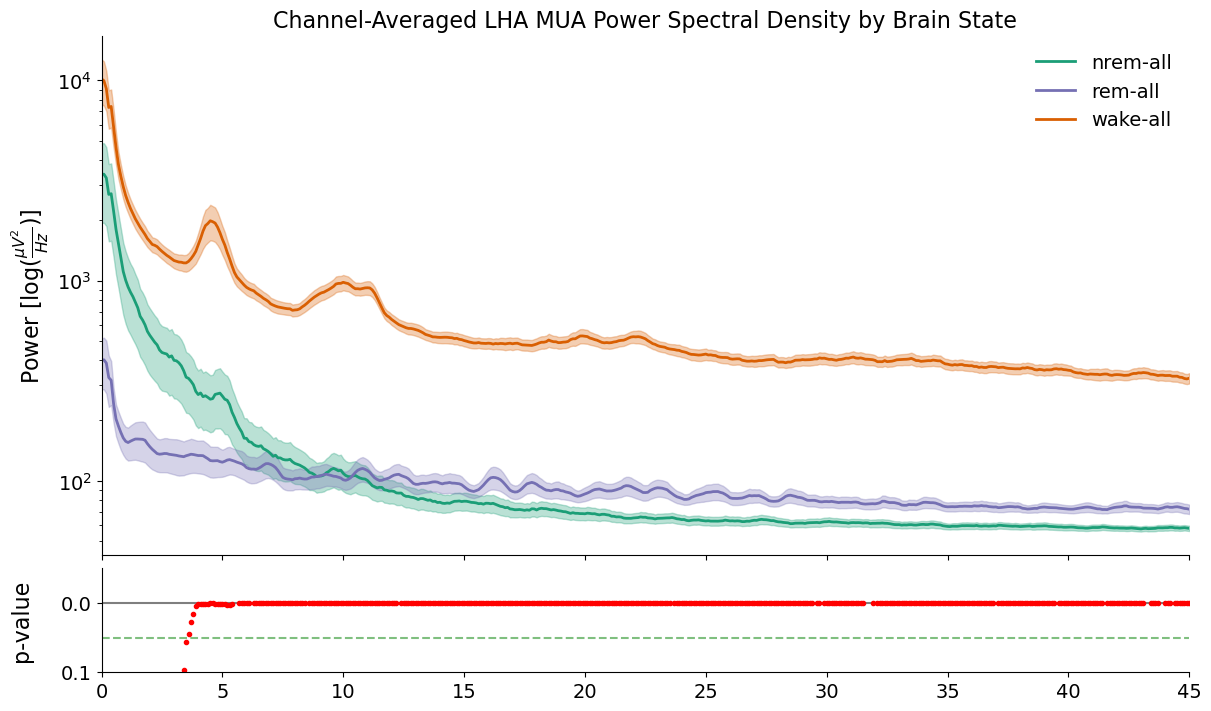

In [ ]:
state_color_dict = {"nrem-all": "#1b9e77", "rem-all": "#7570b3", "wake-all": "#d95f02"}
# state_color_dict = {"nrem-all": "#d7191c", "rem-all": "#fdae61", "wake-all": "#2c7bb6"}
# state_color_dict = {"nrem-all": "#bdc9e1", "rem-all": "#67a9cf", "wake-all": "#02818a"}
region = "hyp"
fig, axs = plt.subplots(
    nrows=2,
    figsize=(12, 7),
    constrained_layout=True,
    height_ratios=[5, 1],
    sharex=True,
)
ax = axs[0]
for state, state_df_group in state_df.groupby("state"):
    ax.plot(
        state_df_group.freq,
        state_df_group.value["mean"],
        label=state,
        c=state_color_dict[state],
        lw=2,
    )
    ax.fill_between(
        x=state_df_group.freq,
        y1=state_df_group.value["mean"] - state_df_group.value["sem"],
        y2=state_df_group.value["mean"] + state_df_group.value["sem"],
        color=state_color_dict[state],
        alpha=0.3,
    )
    ax.set_yscale("log")
    # ax.set_xscale("log")
ax.set_xlim([0, 45])
# ax.set_ylim([10e-2, 10e3])
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
ax.set_title("Channel-Averaged LHA MUA Power Spectral Density by Brain State")
ax.set_ylabel("Power $[\log(\\frac{\mu V^{2}}{Hz})]$")
ax = axs[1]
p_vals = {
    float(f): f_data["p_value"]
    for f, f_data in stat_res.items()
    if f_data["model"].converged
}
ax.axhline(0.0, ls="-", c="k", alpha=0.5)
ax.axhline(0.05, ls="--", c="g", alpha=0.5)
ax.plot(
    np.array(list(p_vals.keys()), dtype=float),
    np.array(list(p_vals.values())),
    ls="",
    marker=".",
    c="r",
)
ax.spines[["top", "right"]].set_visible(False)
ax.set_ylim([0.1, -0.05])
ax.set_ylabel("p-value", labelpad=20)
# fig.savefig(
#     Path("/gpfs01/born/animal/DanielG/hypo_sleep/figures/", "hyp_mua_psd_state_stats.png"),
#     dpi=500,
#     facecolor="white",
#     transparent=False,
#     bbox_inches="tight",
# )

In [ ]:
state_color_dict = {"nrem-all": "#1b9e77", "rem-all": "#7570b3", "wake-all": "#d95f02"}
state_amp_dict = {
    state: {animal: None for animal in ["HYDO03", "HYDO04"]} for state in states
}
for state, animal_epochs in epoch_state_dict.items():
    for animal, epochs in animal_epochs.items():
        if len(epochs) > 0:
            state_amp_dict[state][animal] = xr.concat(
                [epoch.mean(dim="time") for epoch in epochs], dim="epoch"
            )

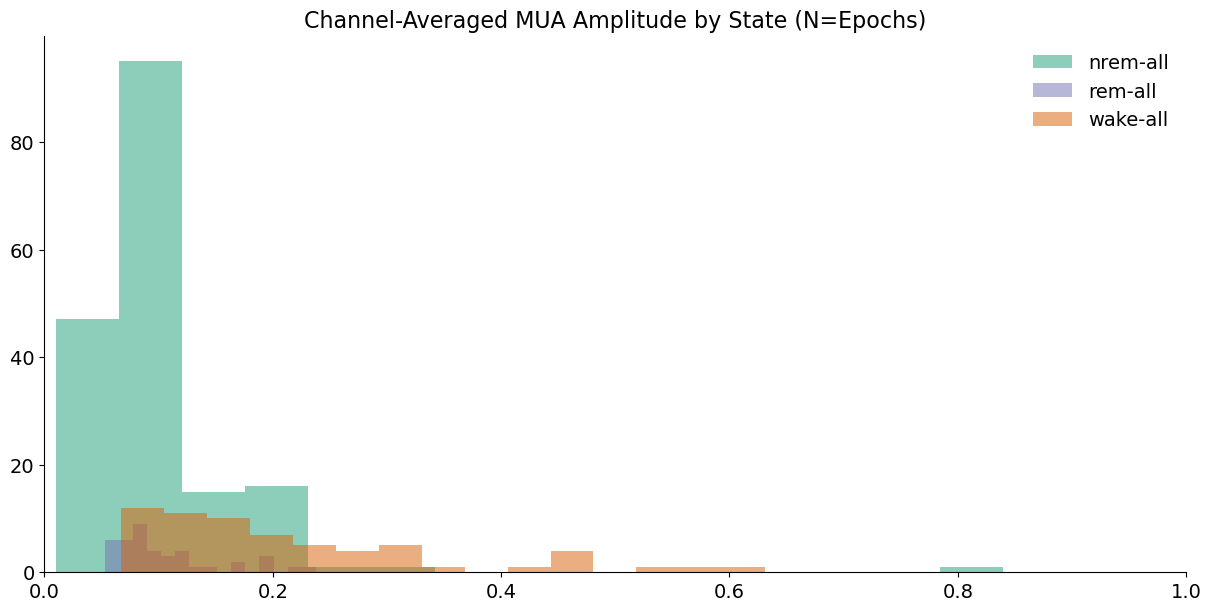

In [132]:
fig, ax = plt.subplots(
    figsize=(12, 6),
    constrained_layout=True,
)
for state, animal_amp in state_amp_dict.items():
    state_amp = xr.concat(animal_amp.values(), dim="epoch")
    amp = state_amp.mean(dim="channel")
    ax.hist(amp.values, bins=15, alpha=0.5, label=state, color=state_color_dict[state])
    ax.set_title("Channel-Averaged MUA Amplitude by State (N=Epochs)")
    ax.set_xlim([0, 1])
    ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)

In [1]:
fig, axs = plt.subplots(
    nrows=16,
    ncols=2,
    figsize=(20, 30),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)
for state, animal_amp in state_amp_dict.items():
    state_amp = xr.concat(animal_amp.values(), dim="epoch")
    for ax, tmp_ch in zip(axs.ravel(), depth_ordered_chs[::-1]):
        amp = state_amp.sel(channel=tmp_ch)
        ax.hist(
            amp.values,
            bins=15,
            alpha=0.5,
            label=state,
            color=state_color_dict[state],
            density=True,
        )
        ax.set_title(tmp_ch)
        ax.set_xlim([0, 0.5])
        ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)

NameError: name 'plt' is not defined

NameError: name 'state_color_dict' is not defined

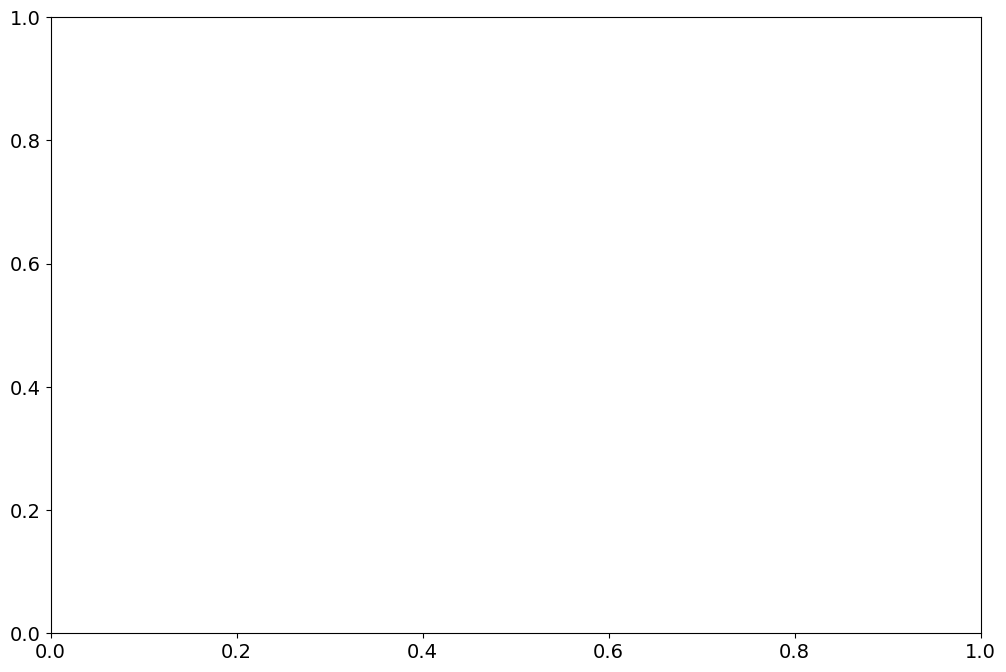

In [128]:
channel = "16"
fig, ax = plt.subplots(figsize=(12, 8))
for state, animal_amp in state_amp_dict.items():
    for animal, amp in animal_amp.items():
        ax.hist(
            amp.sel(channel=channel),
            bins="fd",
            label=f"{state}-{animal}",
            alpha=0.4,
            color=state_color_dict[state],
        )
ax.set_xlim(0, 0.5)
ax.legend()

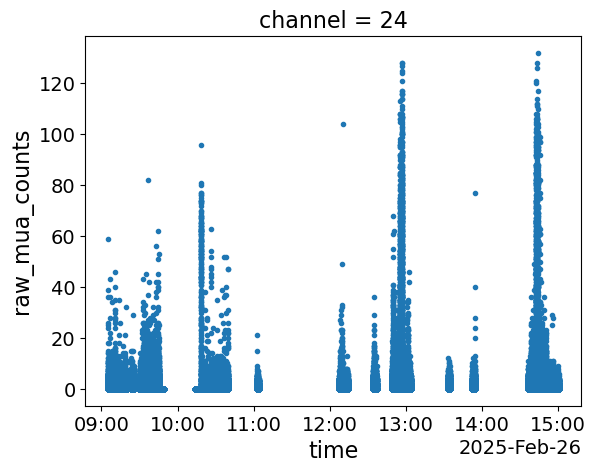

In [34]:
tmp.sel(channel=depth_ordered_chs[0]).plot(marker=".", ls="")

In [36]:
state_data_dict["none"]["2025-02-18_09-19-26"]["nrem-all"]

<xarray.DataArray 'raw_mua_counts' (channel: 32, time: 1718445)> Size: 440MB
array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 3, 0],
       [0, 3, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])
Coordinates:
  * channel  (channel) <U2 256B '26' '27' '10' '28' '11' ... '19' '5' '20' '21'
  * time     (time) datetime64[ns] 14MB 2025-02-18T10:44:56.995000 ... 2025-0...